# Maine Backtest Analysis

## Import Libraries and Data

In [53]:
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

data_2024 = pd.read_csv("maine_2024_polling_backtest.csv")
result_2024 = pd.read_csv("maine_pedersen_index.csv")
data_2020 = pd.read_csv("maine_2020_polling_backtest.csv")
result_2020 = pd.read_csv("maine_pedersen_index.csv")
data_2018 = pd.read_csv("maine_2018_polling_backtest.csv")
result_2018 = pd.read_csv("maine_pedersen_index.csv")
data_2014 = pd.read_csv("maine_2014_polling_backtest.csv")
result_2014 = pd.read_csv("maine_pedersen_index.csv")

## Backtest data from Maine's 2024-2014 polling data and 2024-2014 election end results

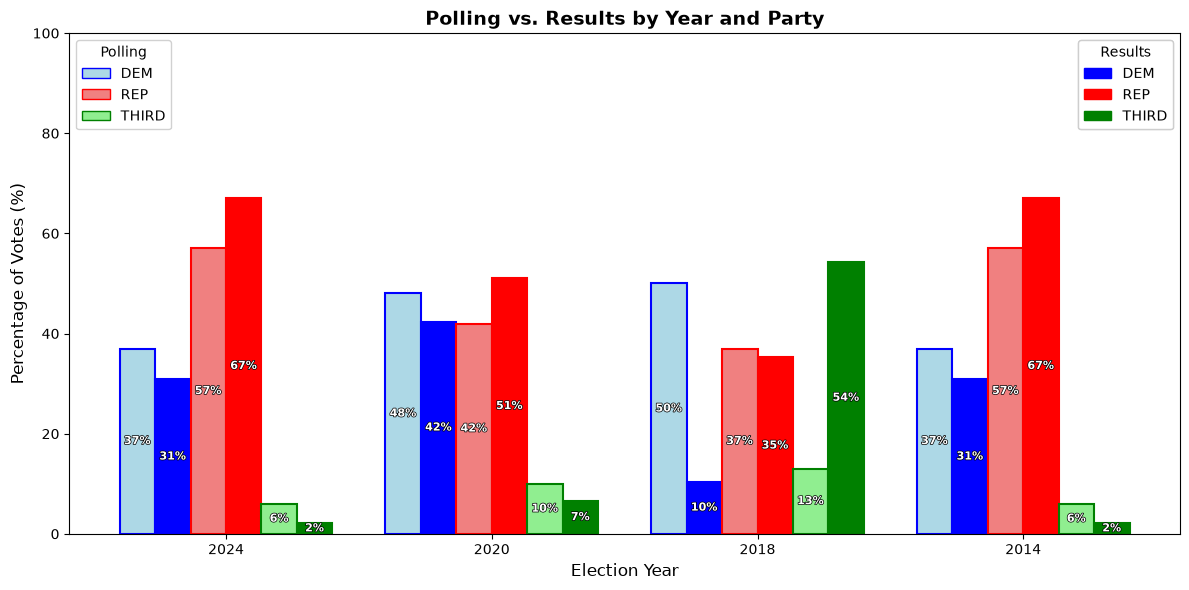

In [54]:
# Retrieve end result from 2024 polling data
democrat_data_2024 = data_2024.iloc[1, 4]
republican_data_2024 = data_2024.iloc[2, 4]
third_party_data_2024 = data_2024.iloc[3, 4]

# Retrieve the actual result from the 2024 election
democrat_result_2024 = result_2024.iloc[0, 4]
republican_result_2024 = result_2024.iloc[1, 4]
third_party_result_2024 = result_2024.iloc[2, 4]

# Retrieve end result from 2020 polling data
democrat_data_2020 = data_2020.iloc[1, 10]
republican_data_2020 = data_2020.iloc[2, 10]
third_party_data_2020 = data_2020.iloc[3, 10]

# Retrieve the actual result from the 2020 election
democrat_result_2020 = result_2020.iloc[0, 3]
republican_result_2020 = result_2020.iloc[1, 3]
third_party_result_2020 = result_2020.iloc[2, 3]

# Retrieve end result from 2018 polling data
democrat_data_2018 = data_2018.iloc[1, 4]
republican_data_2018 = data_2018.iloc[2, 4]
third_party_data_2018 = data_2018.iloc[3, 4]

# Retrieve the actual result from the 2018 election
democrat_result_2018 = result_2018.iloc[0, 2]
republican_result_2018 = result_2018.iloc[1, 2]
third_party_result_2018 = result_2018.iloc[2, 2]

# Retrieve end result from 2014 polling data
democrat_data_2014 = data_2014.iloc[1, 8]
republican_data_2014 = data_2014.iloc[2, 8]
third_party_data_2014 = data_2014.iloc[3, 8]

# Retrieve the actual result from the 2014 election
democrat_result_2014 = result_2014.iloc[0, 1]
republican_result_2014 = result_2014.iloc[1, 1]
third_party_result_2014 = result_2014.iloc[2, 1]

polling_percentages_2024 = [
    float(democrat_data_2014),
    float(republican_data_2014),
    float(third_party_data_2014),
]

result_percentages_2024 = [
    float(democrat_result_2014),
    float(republican_result_2014),
    float(third_party_result_2014),
]

polling_percentages_2020 = [
    float(democrat_data_2020),
    float(republican_data_2020),
    float(third_party_data_2020),
]

result_percentages_2020 = [
    float(democrat_result_2020),
    float(republican_result_2020),
    float(third_party_result_2020),
]

polling_percentages_2018 = [
    float(democrat_data_2018),
    float(republican_data_2018),
    float(third_party_data_2018),
]

result_percentages_2018 = [
    float(democrat_result_2018),
    float(republican_result_2018),
    float(third_party_result_2018),
]

polling_percentages_2014 = [
    float(democrat_data_2014),
    float(republican_data_2014),
    float(third_party_data_2014),
]

result_percentages_2014 = [
    float(democrat_result_2014),
    float(republican_result_2014),
    float(third_party_result_2014),
]

data_bar_chart = [
    {"polling": polling_percentages_2024, "result": result_percentages_2024},
    {"polling": polling_percentages_2020, "result": result_percentages_2020},
    {"polling": polling_percentages_2018, "result": result_percentages_2018},
    {"polling": polling_percentages_2014, "result": result_percentages_2014},
]

years = ["2024", "2020", "2018", "2014"]
parties = ["DEM", "REP", "THIRD"]
categories = ["polling", "result"]

# Setup of offset positions for each bar within a year cluster
n_years = len(years)
n_parties = len(parties)
n_cats = len(categories)

# Total bars per year cluster
bars_per_year = n_parties * n_cats

# Bar width: leave a small gap between year clusters
total_width = 0.8
bar_width = total_width / bars_per_year  # ~0.133

# Base x-positions for each year cluster
x = np.arange(n_years)

def bar_offset(k, n):
    """Center k-th of n bars around x=0."""
    return (k - (n - 1) / 2) * bar_width

# Party styles: face color, edge color, hatch pattern
party_styles = {
    "DEM": {"polling_face": "lightblue", "result_face": "blue", "edge": "blue"},
    "REP": {"polling_face": "lightcoral", "result_face": "red", "edge": "red"},
    "THIRD": {"polling_face": "lightgreen", "result_face": "green", "edge": "green"},
}

fig, ax = plt.subplots(figsize=(12, 6))

for year_idx, entry in enumerate(data_bar_chart):
    k = 0  # bar index within this year cluster
    for party in parties:
        for cat in categories:
            offset = bar_offset(k, bars_per_year)
            style = party_styles[party]
            value = entry[cat][parties.index(party)]

            # Select the face color based on the category
            face_key = f"{cat}_face"
            bar = ax.bar(
                x[year_idx] + offset,
                value,
                width=bar_width,
                color=party_styles[party][face_key],
                edgecolor=style["edge"],
                linewidth=1.5,
                alpha=1.0,
            )
            # Value label above each bar
            ax.text(
                x[year_idx] + offset,
                value / 2,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                fontweight="bold",
                path_effects=[pe.withStroke(linewidth=1, foreground="black")],
            )
            k += 1

# X-axis: one tick per year, centered
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel("Election Year", fontsize=12)
ax.set_ylabel("Percentage of Votes (%)", fontsize=12)
ax.set_title("Polling vs. Results by Year and Party", fontsize=14, fontweight="bold")
ax.set_ylim(0, 100)

# --- Two legends ---
# 1. Polling Colors
party_legend = [
    Patch(facecolor=party_styles[p]["polling_face"], edgecolor=party_styles[p]["result_face"], label=p)
    for p in parties
]

# 2. Result Colors
result_legend = [
    Patch(facecolor=party_styles[p]["result_face"], edgecolor=party_styles[p]["result_face"], label=p)
    for p in parties
]
# Add Polling vs Result legends
leg1 = ax.legend(handles=party_legend, title="Polling", loc="upper left", framealpha=0.9)
ax.add_artist(leg1)
# Add the second legend
leg2 = ax.legend(handles=result_legend, title="Results", loc="upper right", framealpha=0.9)
ax.add_artist(leg2)

plt.tight_layout()
plt.savefig(f"_static/images/maine_backtest.png", dpi=300, bbox_inches="tight")
plt.show()